# Design and Evaluation of Deep Learning Models for Human Physical Activity Recognition from Wearable Sensor Data

**MSc Masters Project — University of the West of Scotland**
**Dataset:** PAMAP2 Physical Activity Monitoring (UCI ML Repository)
**Architectures:** CNN, LSTM, GRU, Hybrid CNN-LSTM
**Evaluation:** Accuracy, Precision, Recall, Macro F1-Score, Confusion Matrix

---

| Section | Content |
|---------|---------|
| **0** | Environment Setup & Imports |
| **1** | Dataset Download & Loading |
| **2** | Exploratory Data Analysis (EDA) |
| **3** | Data Preprocessing Pipeline |
| **4** | Dataset Partitioning & Windowing |
| **5** | Model Architecture Definitions |
| **6** | Model Training |
| **7** | Performance Evaluation & Comparison |
| **8** | Visualisations |
| **9** | Streamlit Interface Code |
| **10** | Summary & Conclusions |

> **Hardware:** Run on Google Colab with GPU (Runtime > Change runtime type > T4 GPU)


## Section 0 — Environment Setup & Imports

In [1]:
# Install any missing packages
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import streamlit
except ImportError:
    install("streamlit")

print("Environment ready.")

Environment ready.


In [2]:
import os, io, zipfile, urllib.request, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
import random; random.seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Devices    : {tf.config.list_physical_devices()}")

TensorFlow : 2.19.0
GPU        : True
Devices    : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Section 1 — Dataset Download & Loading

**PAMAP2 Physical Activity Monitoring Dataset**
- Source: https://archive.ics.uci.edu/dataset/231/pamap2+physical+activity+monitoring
- 9 subjects (101-109), 18 activities, 100 Hz, IMU at wrist/chest/ankle


In [5]:
# ── Section 1 — Dataset Download & Loading ───────────────────────────────────
import os, zipfile, urllib.request

DATASET_URL = "https://archive.ics.uci.edu/static/public/231/pamap2+physical+activity+monitoring.zip"
DATA_DIR    = "PAMAP2_Dataset"

def find_protocol_dir(root):
    """Walk directory tree to find the folder containing .dat files."""
    for dirpath, dirnames, filenames in os.walk(root):
        if any(f.endswith('.dat') for f in filenames):
            return dirpath
    return None

def extract_nested_zips(root):
    """Find and extract any .zip files nested inside an extracted directory."""
    found_nested = True
    while found_nested:
        found_nested = False
        for dirpath, dirnames, filenames in os.walk(root):
            for fname in filenames:
                if fname.endswith('.zip'):
                    nested_path = os.path.join(dirpath, fname)
                    extract_to  = os.path.join(dirpath, fname.replace('.zip', ''))
                    print(f"  Found nested zip: {nested_path}")
                    print(f"  Extracting to   : {extract_to}")
                    with zipfile.ZipFile(nested_path, 'r') as z:
                        z.extractall(extract_to)
                    os.remove(nested_path)
                    found_nested = True

def download_pamap2():
    # Check if already fully extracted
    if os.path.isdir(DATA_DIR):
        existing = find_protocol_dir(DATA_DIR)
        if existing:
            print(f"Dataset already ready. Protocol dir: {existing}")
            return existing

    print("Downloading PAMAP2 (~270 MB) ...")
    zip_path = "pamap2.zip"
    urllib.request.urlretrieve(DATASET_URL, zip_path)

    print("Extracting outer zip ...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    os.remove(zip_path)

    print("Checking for nested zips ...")
    extract_nested_zips(DATA_DIR)

    # Auto-detect Protocol folder wherever .dat files ended up
    protocol_dir = find_protocol_dir(DATA_DIR)
    if protocol_dir is None:
        # Show what IS there to help diagnose
        print("\nExtracted contents:")
        for dirpath, dirnames, filenames in os.walk(DATA_DIR):
            level = dirpath.replace(DATA_DIR, '').count(os.sep)
            indent = '  ' * level
            print(f"{indent}{os.path.basename(dirpath)}/")
            for f in filenames[:5]:
                print(f"{indent}  {f}")
        raise FileNotFoundError("Could not find .dat files. See directory listing above.")

    print(f"Protocol dir: {protocol_dir}")
    return protocol_dir

PROTOCOL_DIR = download_pamap2()

subject_files = sorted([f for f in os.listdir(PROTOCOL_DIR) if f.endswith('.dat')])
print(f"\nSubject files found: {len(subject_files)}")
for f in subject_files:
    print(f"  {f}")

Extracting outer zip ...
Checking for nested zips ...
  Found nested zip: PAMAP2_Dataset/PAMAP2_Dataset.zip
  Extracting to   : PAMAP2_Dataset/PAMAP2_Dataset
Protocol dir: PAMAP2_Dataset/PAMAP2_Dataset/PAMAP2_Dataset/Protocol

Subject files found: 9
  subject101.dat
  subject102.dat
  subject103.dat
  subject104.dat
  subject105.dat
  subject106.dat
  subject107.dat
  subject108.dat
  subject109.dat


In [6]:
# Column names for PAMAP2 (54 columns)
IMU_SENSORS = ["hand", "chest", "ankle"]
IMU_FIELDS  = [
    "temp",
    "acc16_x", "acc16_y", "acc16_z",
    "acc6_x",  "acc6_y",  "acc6_z",
    "gyro_x",  "gyro_y",  "gyro_z",
    "mag_x",   "mag_y",   "mag_z",
    "ori_w",   "ori_x",   "ori_y",   "ori_z"
]

COL_NAMES = ["timestamp", "activity_id", "heart_rate"]
for sensor in IMU_SENSORS:
    for field in IMU_FIELDS:
        COL_NAMES.append(f"{sensor}_{field}")

print(f"Total columns: {len(COL_NAMES)}")

Total columns: 54


In [7]:
# Activity label mapping (PAMAP2 protocol)
ACTIVITY_MAP = {
    1:  "lying",
    2:  "sitting",
    3:  "standing",
    4:  "walking",
    5:  "running",
    6:  "cycling",
    7:  "nordic_walking",
    12: "ascending_stairs",
    13: "descending_stairs",
    16: "vacuum_cleaning",
    17: "ironing",
    24: "rope_jumping"
}

def load_subject(filepath):
    df = pd.read_csv(filepath, sep=' ', header=None, names=COL_NAMES)
    sid = int(os.path.basename(filepath).replace("subject","").replace(".dat",""))
    df["subject_id"] = sid
    return df

dfs = []
for fname in subject_files:
    df = load_subject(os.path.join(PROTOCOL_DIR, fname))
    dfs.append(df)
    print(f"  {fname}: {len(df):,} rows")

raw_df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows : {len(raw_df):,}")
print(f"Subjects   : {sorted(raw_df['subject_id'].unique())}")
print(f"Act codes  : {sorted(raw_df['activity_id'].unique())}")

  subject101.dat: 376,417 rows
  subject102.dat: 447,000 rows
  subject103.dat: 252,833 rows
  subject104.dat: 329,576 rows
  subject105.dat: 374,783 rows
  subject106.dat: 361,817 rows
  subject107.dat: 313,599 rows
  subject108.dat: 408,031 rows
  subject109.dat: 8,477 rows

Total rows : 2,872,533
Subjects   : [np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109)]
Act codes  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]


## Section 2 — Exploratory Data Analysis (EDA)

In [8]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape   : {raw_df.shape}")
print(f"Memory  : {raw_df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print()
print("Missing values (top 10 cols):")
mv = raw_df.isnull().sum()
print(mv[mv > 0].head(10))
print()
print("Activity distribution:")
for aid, cnt in raw_df['activity_id'].value_counts().sort_index().items():
    lbl = ACTIVITY_MAP.get(aid, f"transient({aid})")
    print(f"  {aid:3d}  {lbl:<25s}  {cnt:>8,}")

DATASET OVERVIEW
Shape   : (2872533, 55)
Memory  : 1263.9 MB

Missing values (top 10 cols):
heart_rate      2610265
hand_temp         13141
hand_acc16_x      13141
hand_acc16_y      13141
hand_acc16_z      13141
hand_acc6_x       13141
hand_acc6_y       13141
hand_acc6_z       13141
hand_gyro_x       13141
hand_gyro_y       13141
dtype: int64

Activity distribution:
    0  transient(0)                929,661
    1  lying                       192,523
    2  sitting                     185,188
    3  standing                    189,931
    4  walking                     238,761
    5  running                      98,199
    6  cycling                     164,600
    7  nordic_walking              188,107
   12  ascending_stairs            117,216
   13  descending_stairs           104,944
   16  vacuum_cleaning             175,353
   17  ironing                     238,690
   24  rope_jumping                 49,360


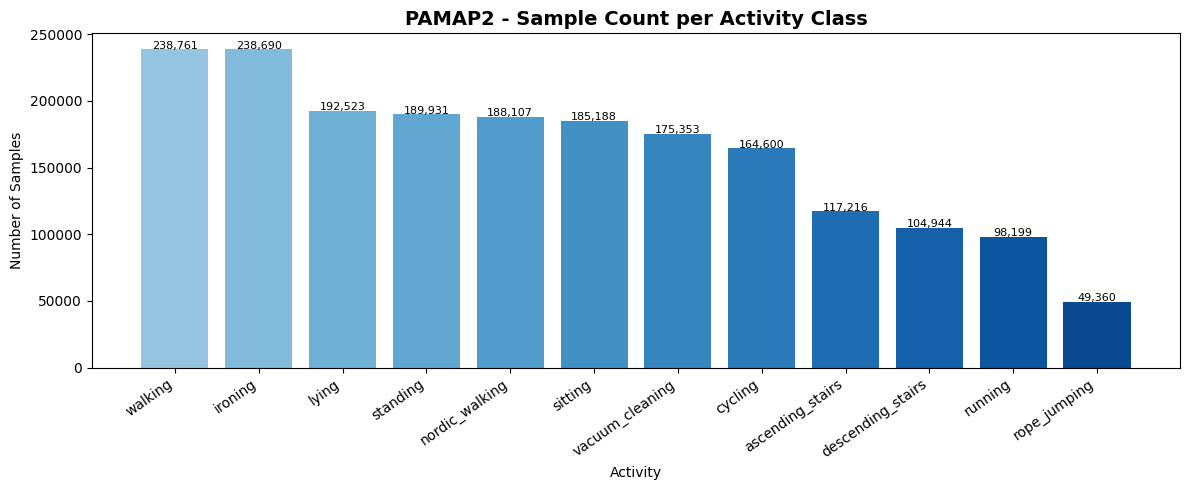

In [9]:
# Plot: Activity class distribution
known_df = raw_df[raw_df['activity_id'].isin(ACTIVITY_MAP)].copy()
counts = known_df.groupby('activity_id').size().reset_index(name='count')
counts['label'] = counts['activity_id'].map(ACTIVITY_MAP)
counts = counts.sort_values('count', ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(counts['label'], counts['count'],
               color=plt.cm.Blues(np.linspace(0.4, 0.9, len(counts))))
plt.title('PAMAP2 - Sample Count per Activity Class', fontsize=14, fontweight='bold')
plt.xlabel('Activity'); plt.ylabel('Number of Samples')
plt.xticks(rotation=35, ha='right')
for bar, v in zip(bars, counts['count']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+400,
             f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('eda_activity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

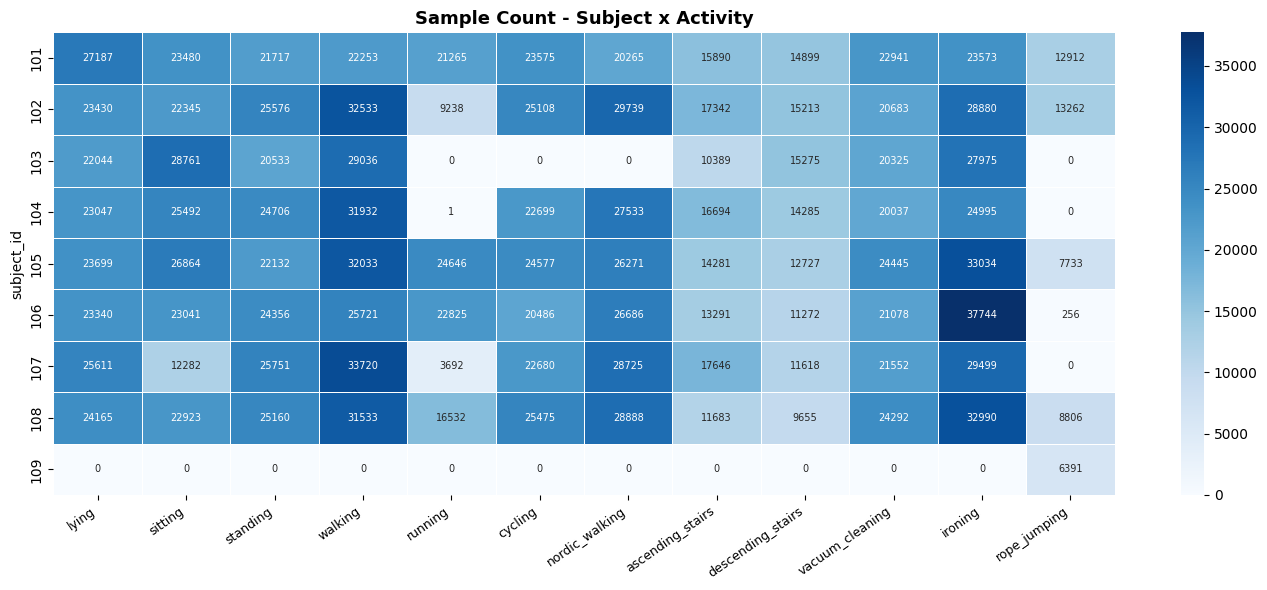

In [10]:
# Plot: Subject x Activity heatmap
pivot = known_df.groupby(['subject_id','activity_id']).size().unstack(fill_value=0)
pivot.columns = [ACTIVITY_MAP[c] for c in pivot.columns]

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues',
            linewidths=0.4, annot_kws={"size": 7})
plt.title('Sample Count - Subject x Activity', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

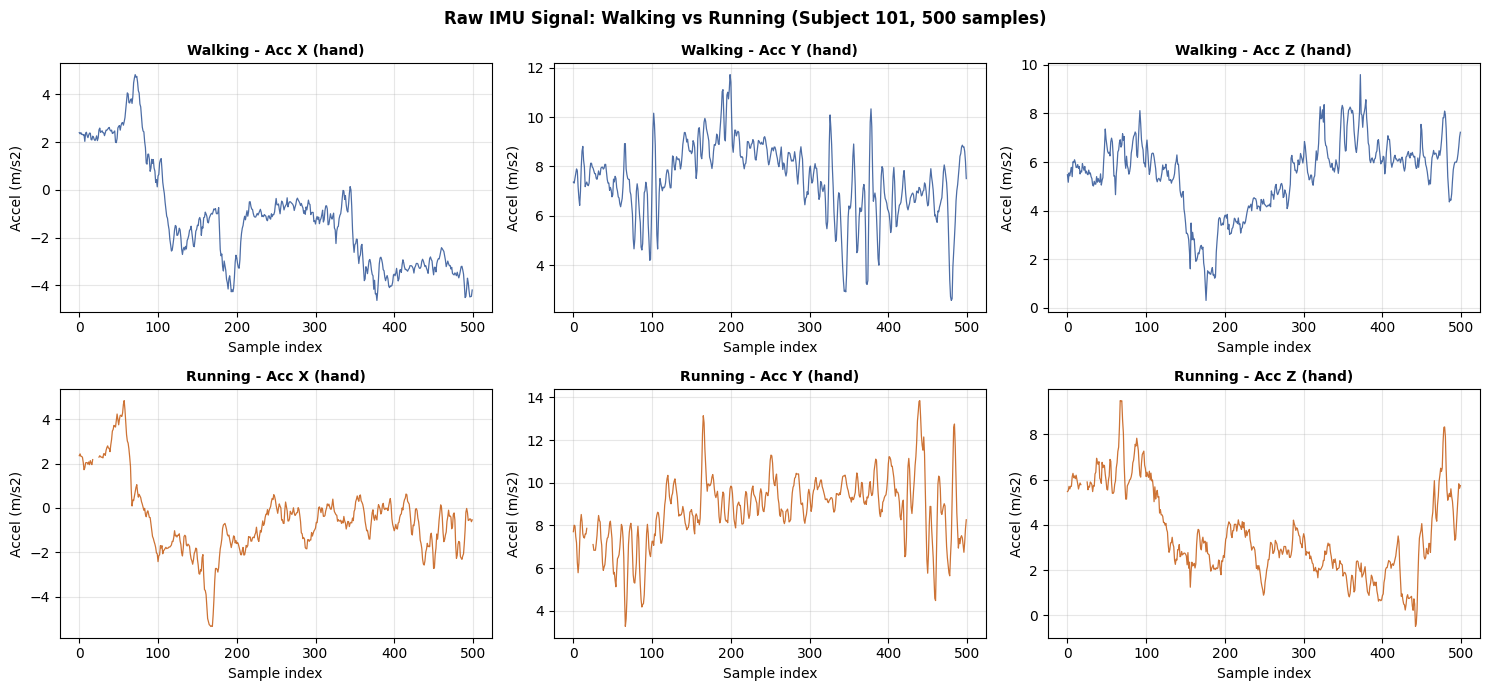

In [11]:
# Plot: Raw signal comparison - walking vs running
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
activities = [(4, 'Walking', '#2E5496'), (5, 'Running', '#C55A11')]
channels   = ['hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z']
labels     = ['Acc X (hand)', 'Acc Y (hand)', 'Acc Z (hand)']

for row, (aid, aname, col) in enumerate(activities):
    seg = known_df[(known_df['subject_id']==101) & (known_df['activity_id']==aid)].head(500)
    for c, (ch, lbl) in enumerate(zip(channels, labels)):
        ax = axes[row][c]
        ax.plot(seg[ch].values, color=col, lw=0.9, alpha=0.85)
        ax.set_title(f'{aname} - {lbl}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Sample index'); ax.set_ylabel('Accel (m/s2)')
        ax.grid(alpha=0.3)

plt.suptitle('Raw IMU Signal: Walking vs Running (Subject 101, 500 samples)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()

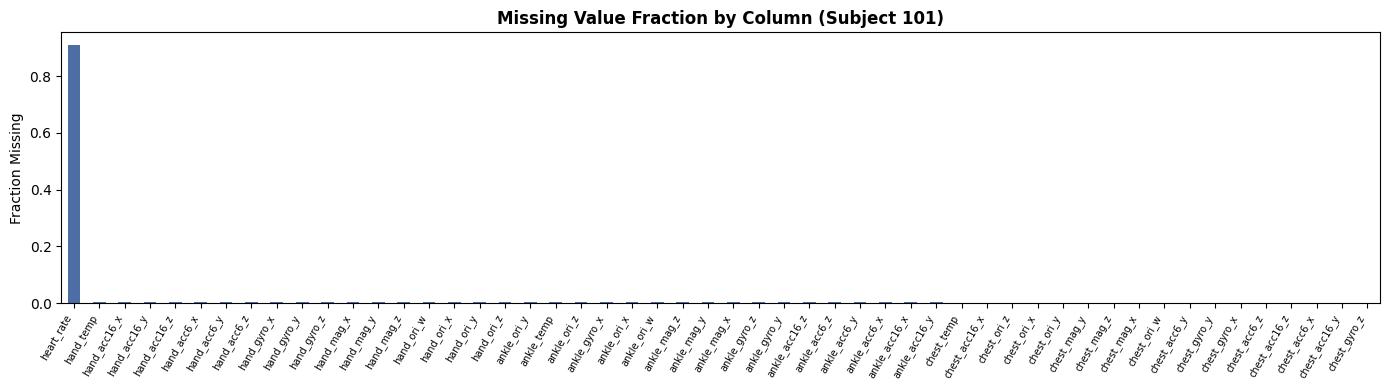

Columns with missing values: 52


In [12]:
# Missing value analysis
subj_mv = raw_df[raw_df['subject_id']==101].isnull().mean()
subj_mv = subj_mv[subj_mv > 0].sort_values(ascending=False)

if len(subj_mv) > 0:
    plt.figure(figsize=(14, 4))
    subj_mv.plot(kind='bar', color='#2E5496', alpha=0.85)
    plt.title('Missing Value Fraction by Column (Subject 101)', fontsize=12, fontweight='bold')
    plt.ylabel('Fraction Missing')
    plt.xticks(rotation=60, ha='right', fontsize=7)
    plt.tight_layout()
    plt.savefig('eda_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Columns with missing values: {len(subj_mv)}")
else:
    print("No missing values in subject 101.")

## Section 3 — Data Preprocessing Pipeline

1. Filter to 12 known activity classes
2. Select feature columns (accelerometer + gyroscope: 18 channels + heart rate)
3. Linear interpolation for missing values
4. Z-score normalisation (fit on train set only)


In [13]:
# Step 3.1 - Filter to known activities
filtered_df = raw_df[raw_df['activity_id'].isin(ACTIVITY_MAP)].copy()
filtered_df['activity_label'] = filtered_df['activity_id'].map(ACTIVITY_MAP)
print(f"Rows before filter : {len(raw_df):,}")
print(f"Rows after filter  : {len(filtered_df):,}")
print("\nClass distribution:")
for lbl, cnt in filtered_df['activity_label'].value_counts().items():
    print(f"  {lbl:<25s} {cnt:>8,}")

Rows before filter : 2,872,533
Rows after filter  : 1,942,872

Class distribution:
  walking                    238,761
  ironing                    238,690
  lying                      192,523
  standing                   189,931
  nordic_walking             188,107
  sitting                    185,188
  vacuum_cleaning            175,353
  cycling                    164,600
  ascending_stairs           117,216
  descending_stairs          104,944
  running                     98,199
  rope_jumping                49,360


In [14]:
# Step 3.2 - Select feature columns
FEATURE_COLS = []
for sensor in IMU_SENSORS:
    for axis in ['x','y','z']:
        FEATURE_COLS.append(f"{sensor}_acc16_{axis}")
    for axis in ['x','y','z']:
        FEATURE_COLS.append(f"{sensor}_gyro_{axis}")
FEATURE_COLS.append("heart_rate")

print(f"Feature columns: {len(FEATURE_COLS)}")
for i, c in enumerate(FEATURE_COLS):
    print(f"  {i+1:2d}. {c}")

Feature columns: 19
   1. hand_acc16_x
   2. hand_acc16_y
   3. hand_acc16_z
   4. hand_gyro_x
   5. hand_gyro_y
   6. hand_gyro_z
   7. chest_acc16_x
   8. chest_acc16_y
   9. chest_acc16_z
  10. chest_gyro_x
  11. chest_gyro_y
  12. chest_gyro_z
  13. ankle_acc16_x
  14. ankle_acc16_y
  15. ankle_acc16_z
  16. ankle_gyro_x
  17. ankle_gyro_y
  18. ankle_gyro_z
  19. heart_rate


In [15]:
# Step 3.3 - Interpolate missing values per subject
def interpolate_subject(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df[FEATURE_COLS] = (
        df[FEATURE_COLS]
        .interpolate(method='linear', limit_direction='both', axis=0)
        .ffill().bfill()
    )
    return df

print("Interpolating per subject ...")
interp_dfs = []
for sid in sorted(filtered_df['subject_id'].unique()):
    sdf = filtered_df[filtered_df['subject_id']==sid].copy()
    sdf = interpolate_subject(sdf)
    mv  = sdf[FEATURE_COLS].isnull().sum().sum()
    interp_dfs.append(sdf)
    print(f"  Subject {sid}: remaining missing = {mv}")

clean_df = pd.concat(interp_dfs, ignore_index=True)
print(f"\nTotal remaining missing: {clean_df[FEATURE_COLS].isnull().sum().sum()}")

Interpolating per subject ...
  Subject 101: remaining missing = 0
  Subject 102: remaining missing = 0
  Subject 103: remaining missing = 0
  Subject 104: remaining missing = 0
  Subject 105: remaining missing = 0
  Subject 106: remaining missing = 0
  Subject 107: remaining missing = 0
  Subject 108: remaining missing = 0
  Subject 109: remaining missing = 0

Total remaining missing: 0


In [16]:
# Step 3.4 - Encode activity labels
le = LabelEncoder()
clean_df['label_enc'] = le.fit_transform(clean_df['activity_label'])

CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Classes (12): ['ascending_stairs', 'cycling', 'descending_stairs', 'ironing', 'lying', 'nordic_walking', 'rope_jumping', 'running', 'sitting', 'standing', 'vacuum_cleaning', 'walking']


## Section 4 — Subject-Independent Partitioning & Sliding Window Segmentation

- **Test subjects**: 105, 106 (withheld entirely)
- **Train/Val subjects**: 101-104, 107-109 (80/20 stratified)
- **Window**: 200 samples = 2 s at 100 Hz
- **Stride**: 100 samples = 50% overlap


In [17]:
TEST_SUBJECTS  = [105, 106]
TRAIN_SUBJECTS = [s for s in sorted(clean_df['subject_id'].unique())
                  if s not in TEST_SUBJECTS]

train_val_df = clean_df[clean_df['subject_id'].isin(TRAIN_SUBJECTS)].copy()
test_df      = clean_df[clean_df['subject_id'].isin(TEST_SUBJECTS)].copy()

print(f"Train+Val subjects : {TRAIN_SUBJECTS}  -> {len(train_val_df):,} rows")
print(f"Test subjects      : {TEST_SUBJECTS}   -> {len(test_df):,} rows")

Train+Val subjects : [np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(107), np.int64(108), np.int64(109)]  -> 1,420,334 rows
Test subjects      : [105, 106]   -> 522,538 rows


In [18]:
WINDOW_SIZE = 200
STRIDE      = 100

def create_windows(df, window_size=WINDOW_SIZE, stride=STRIDE):
    X_list, y_list = [], []
    for sid in df['subject_id'].unique():
        for aid in df['activity_id'].unique():
            seg = df[(df['subject_id']==sid) & (df['activity_id']==aid)]
            if len(seg) < window_size:
                continue
            feats  = seg[FEATURE_COLS].values.astype(np.float32)
            labels = seg['label_enc'].values
            start  = 0
            while start + window_size <= len(feats):
                w_feats  = feats[start:start+window_size]
                w_labels = labels[start:start+window_size]
                X_list.append(w_feats)
                y_list.append(np.bincount(w_labels).argmax())
                start += stride
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)

print("Windowing train+val ...")
X_trainval, y_trainval = create_windows(train_val_df)
print(f"  Shape: {X_trainval.shape}")

print("Windowing test ...")
X_test, y_test = create_windows(test_df)
print(f"  Shape: {X_test.shape}")

Windowing train+val ...
  Shape: (14100, 200, 19)
Windowing test ...
  Shape: (5188, 200, 19)


In [19]:
# Z-score normalisation (fit on train+val only)
n_tv, T, F = X_trainval.shape
scaler = StandardScaler()
X_trainval = scaler.fit_transform(X_trainval.reshape(-1,F)).reshape(n_tv,T,F)

n_te = X_test.shape[0]
X_test = scaler.transform(X_test.reshape(-1,F)).reshape(n_te,T,F)

print("Z-score normalisation applied (train statistics only).")
print(f"  TrainVal mean={X_trainval.mean():.4f} std={X_trainval.std():.4f}")
print(f"  Test     mean={X_test.mean():.4f} std={X_test.std():.4f}")

Z-score normalisation applied (train statistics only).
  TrainVal mean=-0.0000 std=1.0000
  Test     mean=0.0354 std=1.0739


In [20]:
# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=SEED, stratify=y_trainval
)

print(f"Train : {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_val_oh   = to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

# Class weights
cw_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
CLASS_WEIGHTS = {i: w for i, w in enumerate(cw_arr)}
print("\nClass weights:")
for i, cn in enumerate(CLASS_NAMES):
    print(f"  {i:2d} {cn:<25s} {CLASS_WEIGHTS[i]:.3f}")

Train : (11280, 200, 19)  Val: (2820, 200, 19)  Test: (5188, 200, 19)

Class weights:
   0 ascending_stairs          1.326
   1 cycling                   0.989
   2 descending_stairs         1.469
   3 ironing                   0.705
   4 lying                     0.812
   5 nordic_walking            0.874
   6 rope_jumping              2.883
   7 running                   2.344
   8 sitting                   0.875
   9 standing                  0.824
  10 vacuum_cleaning           0.912
  11 walking                   0.652


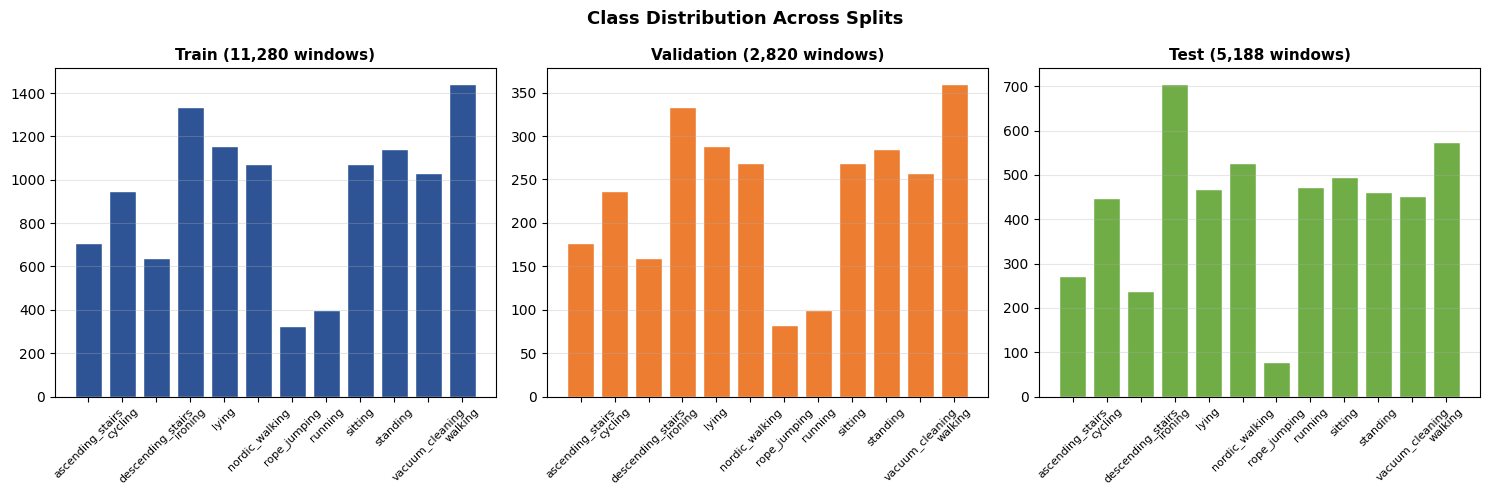

In [21]:
# Plot class distributions across splits
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, y), col in zip(axes,
    [("Train", y_train), ("Validation", y_val), ("Test", y_test)],
    ['#2E5496', '#ED7D31', '#70AD47']):
    counts = np.bincount(y, minlength=NUM_CLASSES)
    ax.bar(CLASS_NAMES, counts, color=col, edgecolor='white')
    ax.set_title(f'{name} ({len(y):,} windows)', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Class Distribution Across Splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — Deep Learning Model Architecture Definitions

Four architectures:
1. **CNN** - 1D Convolutional Neural Network
2. **LSTM** - Long Short-Term Memory (stacked)
3. **GRU** - Gated Recurrent Unit (stacked)
4. **CNN-LSTM** - Hybrid (Conv feature extraction + LSTM sequence modelling)


In [22]:
INPUT_SHAPE  = (WINDOW_SIZE, len(FEATURE_COLS))
DROPOUT_RATE = 0.3
L2_REG       = 1e-4

print(f"Input shape : {INPUT_SHAPE}")
print(f"Num classes : {NUM_CLASSES}")

Input shape : (200, 19)
Num classes : 12


In [23]:
def build_cnn(input_shape, num_classes, dropout=DROPOUT_RATE):
    inputs = keras.Input(shape=input_shape, name="input")
    x = layers.Conv1D(64,  3, padding='same', kernel_regularizer=regularizers.l2(L2_REG))(inputs)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv1D(128, 3, padding='same', kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv1D(256, 3, padding='same', kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)
    return keras.Model(inputs, outputs, name="CNN")

cnn_model = build_cnn(INPUT_SHAPE, NUM_CLASSES)
cnn_model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 200, 19)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 64)        │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 200, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,644 (772.05 KB)

 Trainable params: 196,748 (768.55 KB)

 Non-trainable params: 896 (3.50 KB)

In [24]:
def build_lstm(input_shape, num_classes, dropout=DROPOUT_RATE):
    inputs = keras.Input(shape=input_shape, name="input")
    x = layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(L2_REG))(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(256, return_sequences=False, kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)
    return keras.Model(inputs, outputs, name="LSTM")

lstm_model = build_lstm(INPUT_SHAPE, NUM_CLASSES)
lstm_model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 200, 19)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 200, 128)       │        75,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,460 (1.92 MB)

 Trainable params: 504,460 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
def build_gru(input_shape, num_classes, dropout=DROPOUT_RATE):
    inputs = keras.Input(shape=input_shape, name="input")
    x = layers.GRU(128, return_sequences=True, kernel_regularizer=regularizers.l2(L2_REG))(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.GRU(256, return_sequences=False, kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)
    return keras.Model(inputs, outputs, name="GRU")

gru_model = build_gru(INPUT_SHAPE, NUM_CLASSES)
gru_model.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 200, 19)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 200, 128)       │        57,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 256)            │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,108 (1.48 MB)

 Trainable params: 388,108 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
def build_cnn_lstm(input_shape, num_classes, dropout=DROPOUT_RATE):
    inputs = keras.Input(shape=input_shape, name="input")
    # CNN feature extraction
    x = layers.Conv1D(64,  3, padding='same', kernel_regularizer=regularizers.l2(L2_REG))(inputs)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv1D(128, 3, padding='same', kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    # LSTM sequence modelling
    x = layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(128, return_sequences=False, kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(dropout)(x)
    # Classification head
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout + 0.1)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)
    return keras.Model(inputs, outputs, name="CNN_LSTM")

cnn_lstm_model = build_cnn_lstm(INPUT_SHAPE, NUM_CLASSES)
cnn_lstm_model.summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 200, 19)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 200, 64)        │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,460 (1.25 MB)

 Trainable params: 328,076 (1.25 MB)

 Non-trainable params: 384 (1.50 KB)

In [27]:
# Parameter count summary
models_dict = {"CNN": cnn_model, "LSTM": lstm_model, "GRU": gru_model, "CNN-LSTM": cnn_lstm_model}
print(f"{'Model':<12} {'Trainable Params':>20}")
print("-" * 35)
for name, m in models_dict.items():
    print(f"{name:<12} {m.count_params():>20,}")

Model            Trainable Params
-----------------------------------
CNN                       197,644
LSTM                      504,460
GRU                       388,108
CNN-LSTM                  328,460


## Section 6 — Model Training

**Unified configuration for all models:**
- Optimiser: Adam (lr=0.001)
- Loss: Categorical Cross-Entropy
- Batch size: 64, Max epochs: 50
- Early stopping: patience=10 (monitor val_loss)
- LR reduction on plateau: factor=0.5, patience=5
- Class weighting: inverse frequency


In [29]:
BATCH_SIZE = 64
MAX_EPOCHS = 10
INIT_LR    = 1e-3
os.makedirs("saved_models", exist_ok=True)

def compile_and_train(model, name, X_tr, y_tr, X_v, y_v):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=INIT_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f"saved_models/{name}_best.keras", monitor='val_loss',
                        save_best_only=True, verbose=0)
    ]
    print(f"\n{'='*55}\n  Training: {name}\n{'='*55}")
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=CLASS_WEIGHTS,
        callbacks=callbacks,
        verbose=1
    )
    return history

histories = {}

In [30]:
cnn_model = build_cnn(INPUT_SHAPE, NUM_CLASSES)
histories['CNN'] = compile_and_train(cnn_model, "CNN", X_train, y_train_oh, X_val, y_val_oh)


  Training: CNN
Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.8540 - loss: 0.5426 - val_accuracy: 0.8883 - val_loss: 0.4085 - learning_rate: 0.0010
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9279 - loss: 0.2859 - val_accuracy: 0.9259 - val_loss: 0.2799 - learning_rate: 0.0010
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9374 - loss: 0.2424 - val_accuracy: 0.9422 - val_loss: 0.2272 - learning_rate: 0.0010
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9444 - loss: 0.2139 - val_accuracy: 0.9429 - val_loss: 0.2263 - learning_rate: 0.0010
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9522 - loss: 0.1928 - val_accuracy: 0.9440 - val_loss: 0.2067 - learning_rate: 0.0010
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9540 - loss: 0.1788 - val_accuracy: 0.9461 - val_loss: 0.2094 - learning_rate: 0.0010
Epoch 7/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.956

In [31]:
lstm_model = build_lstm(INPUT_SHAPE, NUM_CLASSES)
histories['LSTM'] = compile_and_train(lstm_model, "LSTM", X_train, y_train_oh, X_val, y_val_oh)


  Training: LSTM
Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7113 - loss: 0.9654 - val_accuracy: 0.8507 - val_loss: 0.5542 - learning_rate: 0.0010
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8560 - loss: 0.5670 - val_accuracy: 0.8397 - val_loss: 0.5621 - learning_rate: 0.0010
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7941 - loss: 0.7367 - val_accuracy: 0.8450 - val_loss: 0.6197 - learning_rate: 0.0010
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8636 - loss: 0.5224 - val_accuracy: 0.8819 - val_loss: 0.5171 - learning_rate: 0.0010
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8762 - loss: 0.5016 - val_accuracy: 0.8844 - val_loss: 0.4713 - learning_rate: 0.0010
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8976 - loss: 0.4217 - val_accuracy: 0.9021 - val_loss: 0.3799 - learning_rate: 0.0010
Epoch 7/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accurac

In [32]:
gru_model = build_gru(INPUT_SHAPE, NUM_CLASSES)
histories['GRU'] = compile_and_train(gru_model, "GRU", X_train, y_train_oh, X_val, y_val_oh)


  Training: GRU
Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6497 - loss: 1.1278 - val_accuracy: 0.8383 - val_loss: 0.5830 - learning_rate: 0.0010
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8622 - loss: 0.4950 - val_accuracy: 0.8894 - val_loss: 0.3975 - learning_rate: 0.0010
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9043 - loss: 0.3518 - val_accuracy: 0.9202 - val_loss: 0.3080 - learning_rate: 0.0010
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9252 - loss: 0.2871 - val_accuracy: 0.9245 - val_loss: 0.3037 - learning_rate: 0.0010
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9310 - loss: 0.2668 - val_accuracy: 0.9309 - val_loss: 0.2749 - learning_rate: 0.0010
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9376 - loss: 0.2431 - val_accuracy: 0.9301 - val_loss: 0.2708 - learning_rate: 0.0010
Epoch 7/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 

In [33]:
cnn_lstm_model = build_cnn_lstm(INPUT_SHAPE, NUM_CLASSES)
histories['CNN-LSTM'] = compile_and_train(cnn_lstm_model, "CNN-LSTM", X_train, y_train_oh, X_val, y_val_oh)


  Training: CNN-LSTM
Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7636 - loss: 0.8683 - val_accuracy: 0.8819 - val_loss: 0.4985 - learning_rate: 0.0010
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8792 - loss: 0.4812 - val_accuracy: 0.8975 - val_loss: 0.4123 - learning_rate: 0.0010
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8986 - loss: 0.4168 - val_accuracy: 0.8759 - val_loss: 0.5165 - learning_rate: 0.0010
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8782 - loss: 0.4817 - val_accuracy: 0.8961 - val_loss: 0.4040 - learning_rate: 0.0010
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8750 - loss: 0.4534 - val_accuracy: 0.8936 - val_loss: 0.4137 - learning_rate: 0.0010
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9053 - loss: 0.3760 - val_accuracy: 0.9121 - val_loss: 0.3866 - learning_rate: 0.0010
Epoch 7/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accur

In [34]:
# Save all models
trained_models = {
    "CNN": cnn_model, "LSTM": lstm_model,
    "GRU": gru_model, "CNN-LSTM": cnn_lstm_model
}
for name, m in trained_models.items():
    m.save(f"saved_models/{name}_final.keras")
    print(f"Saved: saved_models/{name}_final.keras")

Saved: saved_models/CNN_final.keras
Saved: saved_models/LSTM_final.keras
Saved: saved_models/GRU_final.keras
Saved: saved_models/CNN-LSTM_final.keras


## Section 7 — Performance Evaluation & Comparison

All models evaluated on the **held-out test set** (subjects 105 & 106).
Primary metric: **Macro-averaged F1-Score** (robust to class imbalance).


In [35]:
results = {}

for name, model in trained_models.items():
    y_pred_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
    results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1_macro': f1, 'y_pred': y_pred, 'y_pred_prob': y_pred_prob, 'cm': cm
    }
    print(f"{name:<12} Acc={acc:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f}")

CNN          Acc=0.8770 Prec=0.8754 Rec=0.8744 F1=0.8746
LSTM         Acc=0.8275 Prec=0.8270 Rec=0.8195 F1=0.8190
GRU          Acc=0.8655 Prec=0.8689 Rec=0.8643 F1=0.8644
CNN-LSTM     Acc=0.8635 Prec=0.8780 Rec=0.8641 F1=0.8693


In [36]:
for name, res in results.items():
    print(f"\n{'='*65}")
    print(f"  {name} - Full Classification Report")
    print(f"{'='*65}")
    print(classification_report(y_test, res['y_pred'],
                                target_names=CLASS_NAMES, zero_division=0, digits=4))


  CNN - Full Classification Report
                   precision    recall  f1-score   support

 ascending_stairs     0.8316    0.8713    0.8510       272
          cycling     0.9650    0.9262    0.9452       447
descending_stairs     0.7935    0.8270    0.8099       237
          ironing     0.8416    0.8894    0.8648       705
            lying     0.9587    0.9443    0.9515       467
   nordic_walking     0.9614    0.9468    0.9540       526
     rope_jumping     0.9091    0.9091    0.9091        77
          running     0.9553    0.9047    0.9293       472
          sitting     0.7389    0.7702    0.7542       496
         standing     0.7166    0.6840    0.6999       462
  vacuum_cleaning     0.8848    0.8496    0.8668       452
          walking     0.9490    0.9704    0.9596       575

         accuracy                         0.8770      5188
        macro avg     0.8754    0.8744    0.8746      5188
     weighted avg     0.8783    0.8770    0.8773      5188


  LSTM - Full Cl

In [37]:
summary_df = pd.DataFrame({
    'Model':      list(results.keys()),
    'Accuracy':   [results[m]['accuracy']  for m in results],
    'Precision':  [results[m]['precision'] for m in results],
    'Recall':     [results[m]['recall']    for m in results],
    'F1 (Macro)': [results[m]['f1_macro']  for m in results],
}).set_index('Model').sort_values('F1 (Macro)', ascending=False)

print("\n" + "="*65)
print("  MODEL COMPARISON - TEST SET (Subjects 105 & 106)")
print("="*65)
print(summary_df.to_string(float_format='{:.4f}'.format))
print("="*65)
best_model = summary_df.index[0]
print(f"\n  Best model: {best_model}  (F1={summary_df.loc[best_model,'F1 (Macro)']:.4f})")

summary_df.to_csv("model_comparison_results.csv")
print("  Saved: model_comparison_results.csv")


  MODEL COMPARISON - TEST SET (Subjects 105 & 106)
          Accuracy  Precision  Recall  F1 (Macro)
Model                                            
CNN         0.8770     0.8754  0.8744      0.8746
CNN-LSTM    0.8635     0.8780  0.8641      0.8693
GRU         0.8655     0.8689  0.8643      0.8644
LSTM        0.8275     0.8270  0.8195      0.8190

  Best model: CNN  (F1=0.8746)
  Saved: model_comparison_results.csv


## Section 8 — Visualisations

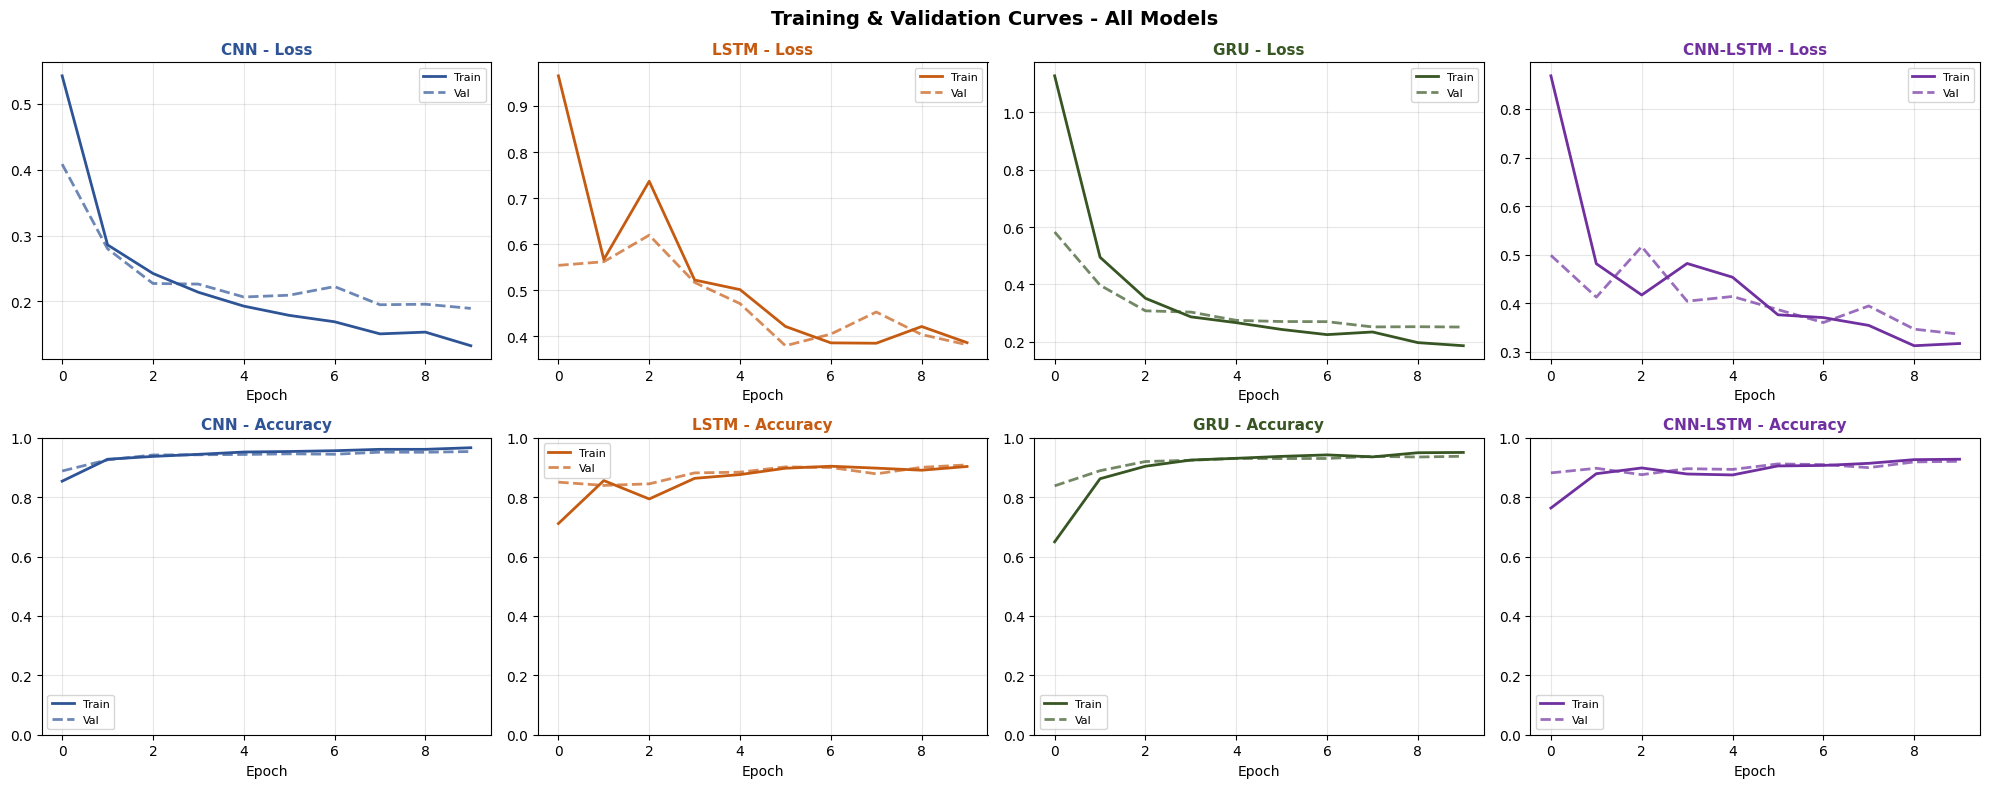

Saved: training_curves.png


In [38]:
# Training curves - all models
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
model_colors = {'CNN':'#2E5496','LSTM':'#C55A11','GRU':'#375623','CNN-LSTM':'#7030A0'}

for col, (name, col_color) in enumerate(model_colors.items()):
    hist = histories[name].history
    axes[0][col].plot(hist['loss'],     label='Train', color=col_color, lw=2)
    axes[0][col].plot(hist['val_loss'], label='Val',   color=col_color, lw=2, ls='--', alpha=0.7)
    axes[0][col].set_title(f'{name} - Loss', fontsize=11, fontweight='bold', color=col_color)
    axes[0][col].set_xlabel('Epoch'); axes[0][col].legend(fontsize=8); axes[0][col].grid(alpha=0.3)

    axes[1][col].plot(hist['accuracy'],     label='Train', color=col_color, lw=2)
    axes[1][col].plot(hist['val_accuracy'], label='Val',   color=col_color, lw=2, ls='--', alpha=0.7)
    axes[1][col].set_title(f'{name} - Accuracy', fontsize=11, fontweight='bold', color=col_color)
    axes[1][col].set_xlabel('Epoch'); axes[1][col].set_ylim(0,1)
    axes[1][col].legend(fontsize=8); axes[1][col].grid(alpha=0.3)

plt.suptitle('Training & Validation Curves - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

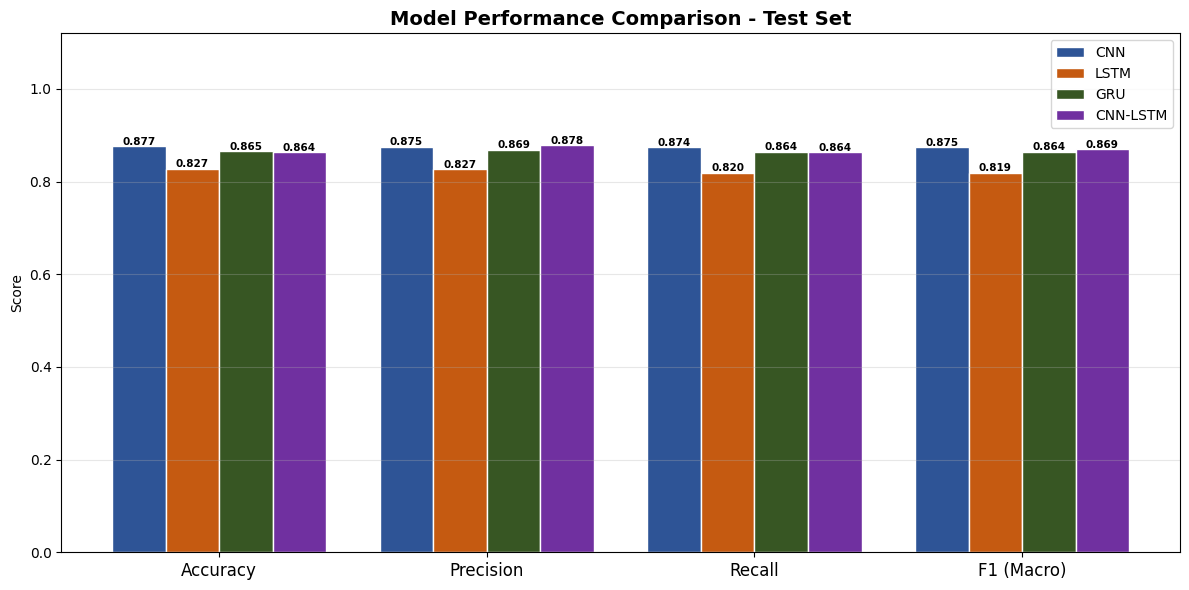

Saved: model_comparison_bars.png


In [39]:
# Performance bar chart
metrics = ['Accuracy','Precision','Recall','F1 (Macro)']
x, width = np.arange(len(metrics)), 0.20
fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, col) in enumerate(model_colors.items()):
    vals = [results[name]['accuracy'], results[name]['precision'],
            results[name]['recall'],   results[name]['f1_macro']]
    bars = ax.bar(x + i*width, vals, width, label=name, color=col, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.3f}', ha='center', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width*1.5); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.12)
ax.set_title('Model Performance Comparison - Test Set', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_bars.png")

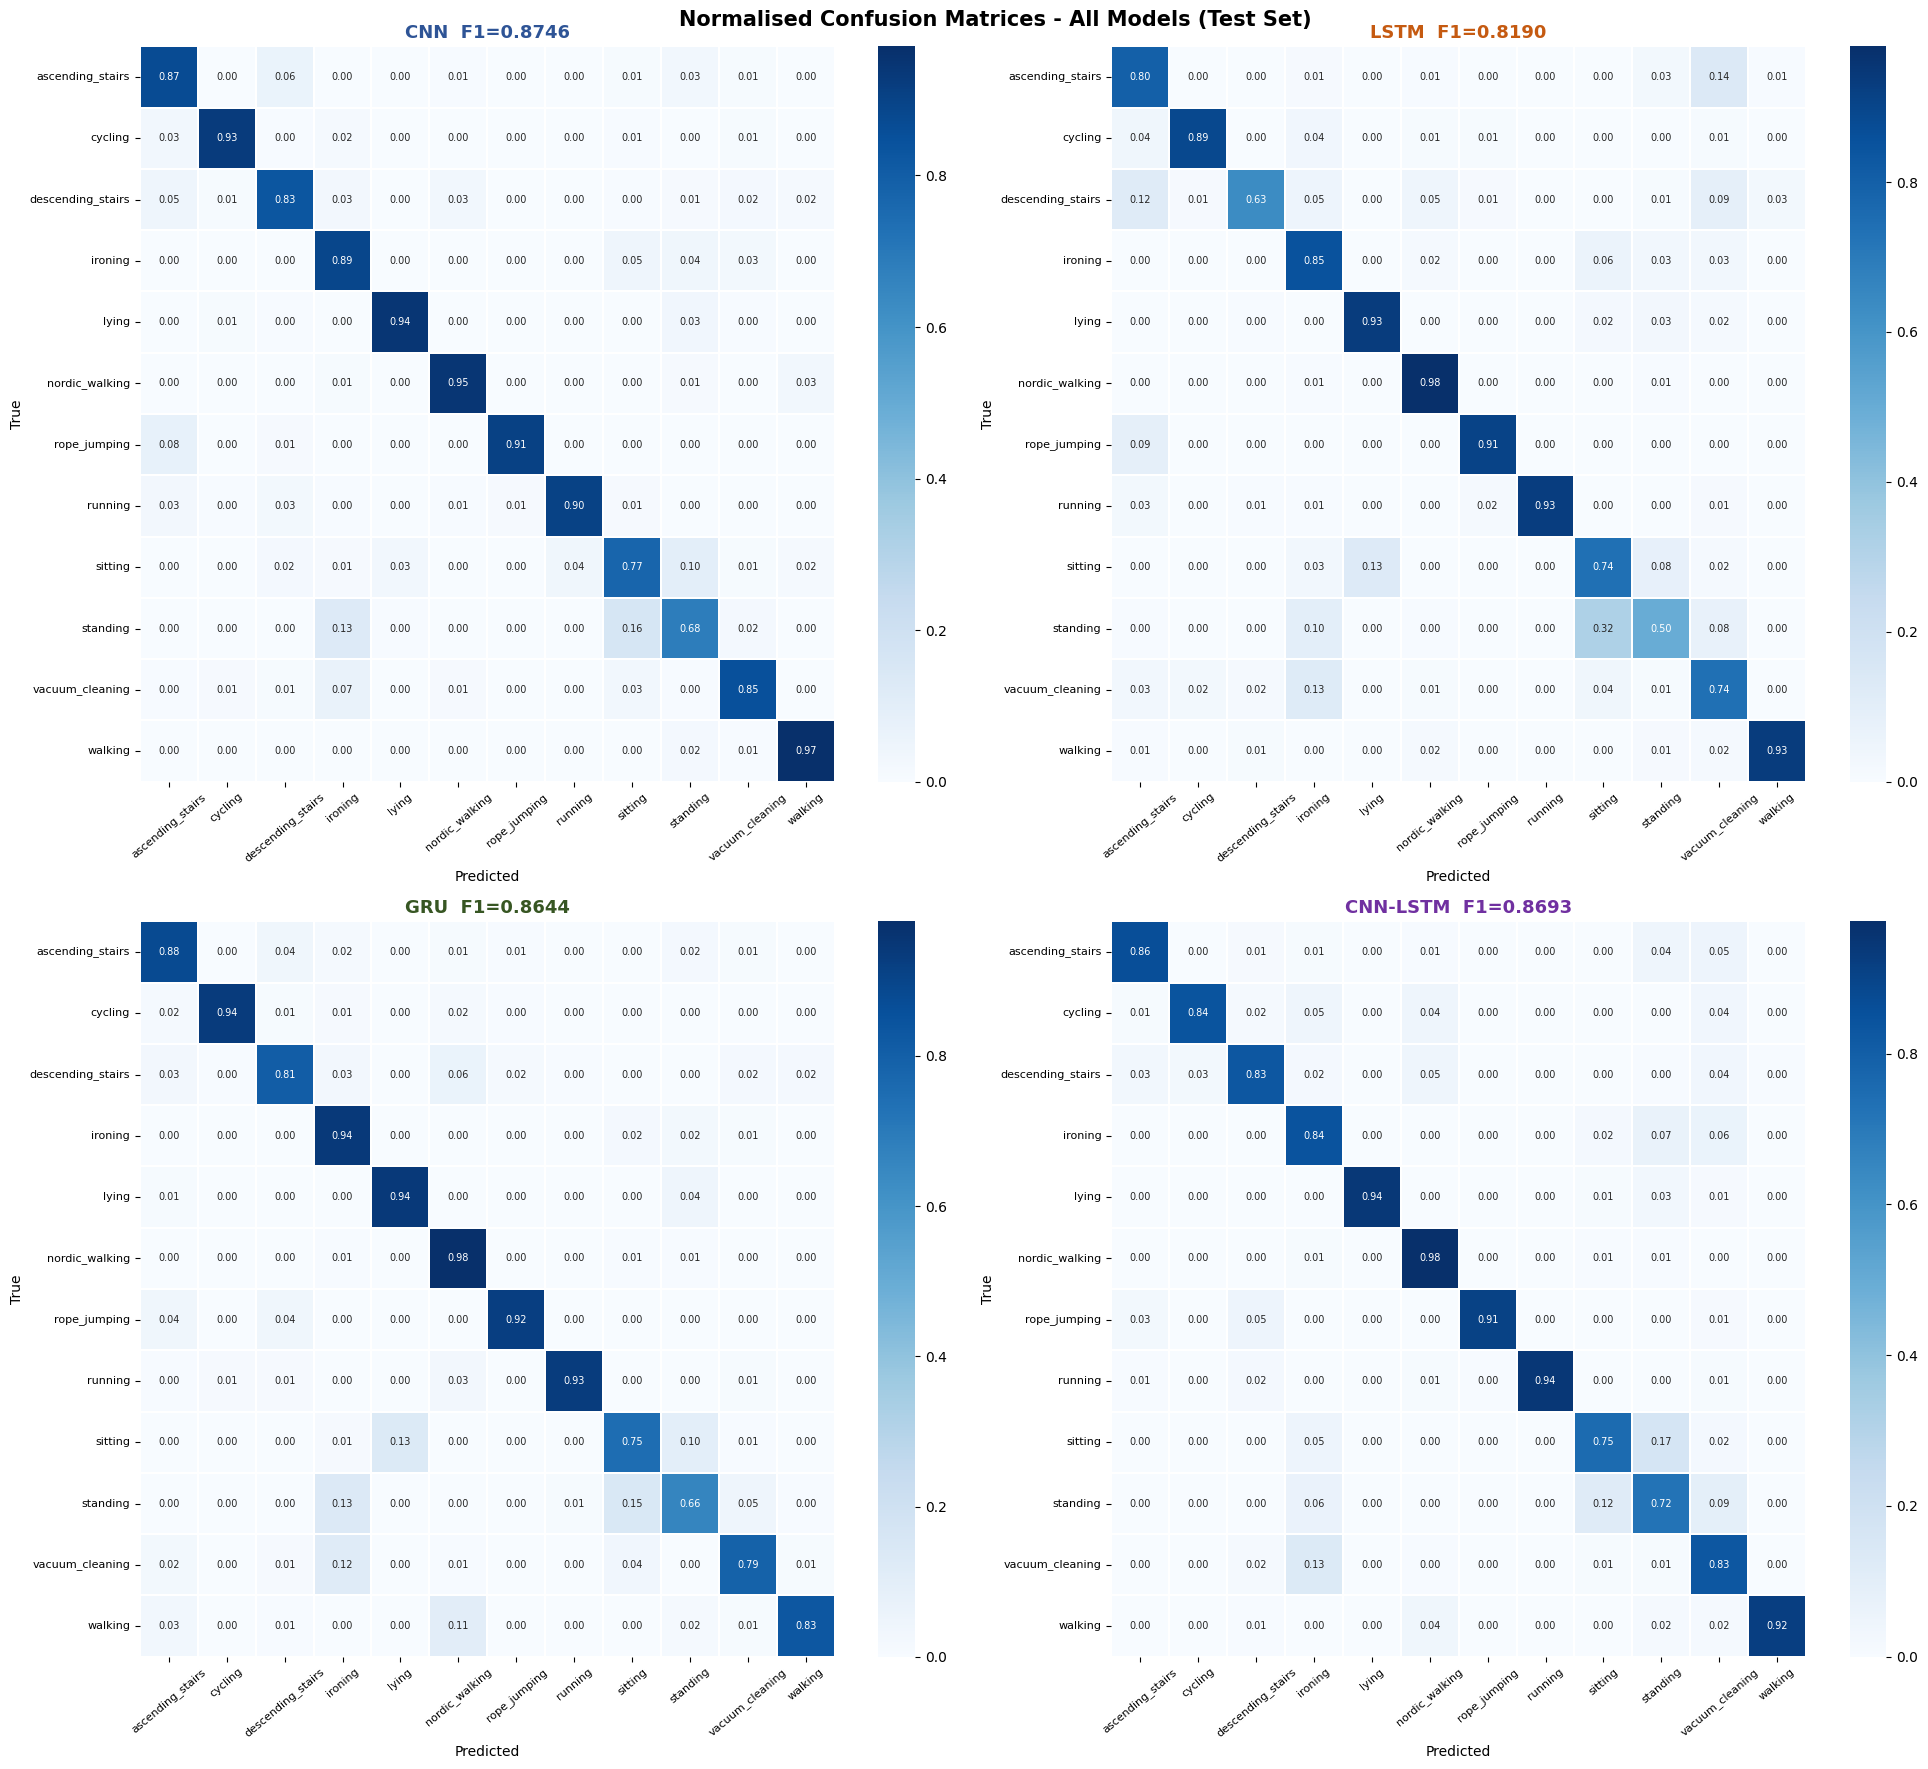

Saved: confusion_matrices.png


In [40]:
# Confusion matrices (normalised)
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
for idx, (name, res) in enumerate(results.items()):
    ax = axes.flatten()[idx]
    cm_norm = res['cm'].astype('float') / res['cm'].sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.3, annot_kws={"size":7})
    ax.set_title(f'{name}  F1={res["f1_macro"]:.4f}',
                 fontsize=13, fontweight='bold', color=model_colors[name])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Normalised Confusion Matrices - All Models (Test Set)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

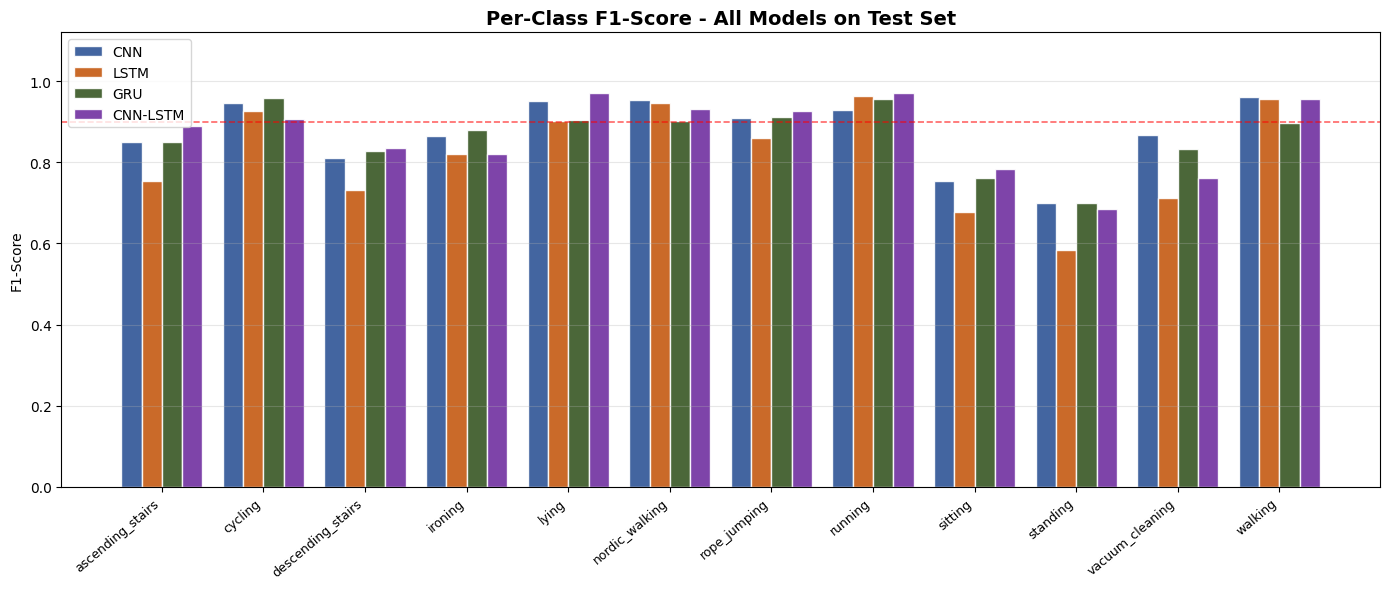

Saved: per_class_f1.png


In [41]:
# Per-class F1 comparison
fig, ax = plt.subplots(figsize=(14, 6))
x_pos, width = np.arange(NUM_CLASSES), 0.20

for i, (name, col) in enumerate(model_colors.items()):
    pc_f1 = f1_score(y_test, results[name]['y_pred'], average=None, zero_division=0)
    ax.bar(x_pos + i*width, pc_f1, width, label=name, color=col, edgecolor='white', alpha=0.90)

ax.set_xticks(x_pos + width*1.5)
ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('F1-Score'); ax.set_ylim(0, 1.12)
ax.set_title('Per-Class F1-Score - All Models on Test Set', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.axhline(0.9, color='red', ls='--', lw=1.2, alpha=0.6)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_class_f1.png")

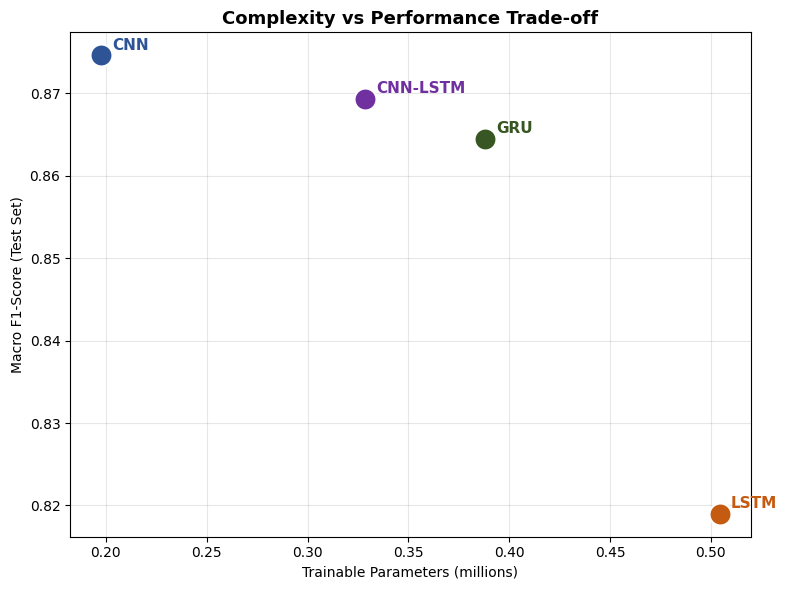

Saved: params_vs_f1.png


In [42]:
# Complexity vs performance
fig, ax = plt.subplots(figsize=(8, 6))
for name, col in model_colors.items():
    params = trained_models[name].count_params()
    f1     = results[name]['f1_macro']
    ax.scatter(params/1e6, f1, s=250, color=col, zorder=5, edgecolors='white', lw=1.5)
    ax.annotate(name, (params/1e6, f1), textcoords="offset points",
                xytext=(8, 4), fontsize=11, fontweight='bold', color=col)

ax.set_xlabel('Trainable Parameters (millions)')
ax.set_ylabel('Macro F1-Score (Test Set)')
ax.set_title('Complexity vs Performance Trade-off', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('params_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: params_vs_f1.png")